# 13 — Final statistical tests

**Single source of truth for reportable inferential results.**

This notebook contains only the tests prepared for the thesis / paper / presentation.
It does **not** fish new topics. Constructs are frozen (H3/H4 manual freeze applied).

> Once this notebook runs, do **not** redefine constructs because of its results.
> Notebook 14 is for interpretation and presentation only.

## Section 0 — Final frozen analysis definition

| Item | Value |
| --- | --- |
| Corpus | ~16,000 analysable books (v3 English romance) |
| Topic model | Stage 05 final fit (`v4_l12_granular_final_call49`) |
| Primary outcome | `rating_shrunk` |
| Secondary outcome | `log_n_ratings` (discriminant; not H1–H6 support) |
| Effect gate | \(\lvert\delta\rvert \ge 0.11\) |
| Controls | `log_pages`, `n_sentences`, `publication_year`, `genre_group` |
| Uncertainty | author-cluster bootstrap CI for δ; cluster-robust SE for OLS |
| FDR family | six primary H1–H6 tests only (BH) |
| Freeze | `human_review/h3_manual_freeze.json`, `h4_manual_freeze.json` |
| Claim hierarchy | `human_review/post_freeze_claim_hierarchy.md` |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage10_correlation_analysis.analysis import tests as tst
from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import presentation as pres

ctx = nh.setup("13_final_statistical_tests")
cfg = ctx.cfg
GATE = nh.effect_gate(cfg)
coverage = nh.load_construct_coverage(cfg)
delta_freeze = cfg.section("stage10_delta_freeze")

N_BOOT = 400  # author-cluster replicates for final CIs
SEED = 42

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests


## Section 1 — Data and outcome sanity check

In [2]:
frame = nh.load_refined_frame(cfg, "strict")
if "book_id" in frame.columns:
    frame = frame.set_index("book_id")
usable = frame[frame["analysable"].fillna(True)].copy() if "analysable" in frame.columns else frame.copy()
work = usable.reset_index()

sanity = pd.DataFrame(
    [
        {"metric": "n_books", "value": float(len(work))},
        {
            "metric": "n_authors",
            "value": float(work["author_id"].nunique()) if "author_id" in work.columns else float("nan"),
        },
        {
            "metric": "rating_shrunk_mean",
            "value": float(work["rating_shrunk"].mean()) if "rating_shrunk" in work.columns else float("nan"),
        },
        {
            "metric": "rating_shrunk_median",
            "value": float(work["rating_shrunk"].median()) if "rating_shrunk" in work.columns else float("nan"),
        },
        {
            "metric": "quality_reach_corr",
            "value": float(work["rating_shrunk"].corr(work["log_n_ratings"]))
            if {"rating_shrunk", "log_n_ratings"} <= set(work.columns)
            else float("nan"),
        },
    ]
)
tier_counts = (
    work["rating_class"].value_counts().rename_axis("tier").reset_index(name="n")
    if "rating_class" in work.columns
    else pd.DataFrame()
)
display(sanity)
display(tier_counts)
ctx.save_table(sanity, "sanity_summary")
if len(tier_counts):
    ctx.save_table(tier_counts, "tier_sizes")

,metric,value
0,n_books,"15,999.0000"
1,n_authors,"8,263.0000"
2,rating_shrunk_mean,3.9220
3,rating_shrunk_median,3.9140
4,quality_reach_corr,0.2062


,tier,n
0,mid_rate,5524
1,low_rate,5389
2,high_rate,5086


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/sanity_summary.csv  (5 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/tier_sizes.csv  (3 rows)


## Sections 2–9 — Primary H1–H6 + inferential stack

Cliff's δ (ordering), author-cluster CI, Kruskal–Wallis + ε², Spearman tier trend,
adjusted OLS with author-cluster SE. FDR only on the six primaries.

In [3]:
PRIMARY = [
    ("H1", "RLR_emotional_vs_explicit", "emotional vs explicit ratio", +1),
    ("H2", "RAX_h2_strict", "strict final payoff", +1),
    ("H3", "RLR_emotional_vs_material_security", "emotional vs material security", +1),
    ("H4", "RLR_protection_vs_control", "protection vs possession", +1),
    ("H5", "RLR_darkness_vs_tenderness", "darkness vs tenderness", +1),
    ("H6", "RARC", "refined arc contrast", +1),
]

COMPONENTS = [
    ("H1", "RAX_emotional_reassurance", "emotional reassurance", None),
    ("H1", "RAX_explicit_sex", "explicit sex", None),
    ("H1", "RAX_nonexplicit_affection", "non-explicit affection", None),
    ("H3", "RAX_h3_emotional_side", "emotional security side", None),
    ("H3", "RAX_h3_material_side", "material provision side", None),
    ("H3", "RAX_appearance_grooming", "appearance / grooming", None),
    ("H4", "RAX_external_protection", "external protection (atom)", None),
    ("H4", "RAX_protective_commitment", "protective commitment", None),
    ("H4", "RAX_h4_possession_side", "possession / control", None),
    ("H5", "RAX_tenderness_core", "tenderness core", None),
    ("H5", "RAX_external_danger_crisis", "external danger / crisis", None),
    ("H5", "RAX_individual_distress", "individual distress", None),
    ("H5", "RAX_relational_darkness", "relational darkness", None),
    ("H6", "DELTA_rising", "rising Δ (end−begin)", None),
    ("H6", "DELTA_falling", "falling Δ (end−begin)", None),
]

PRIMARY_FEATURES = {f for _, f, _, _ in PRIMARY}

print("Running primary + component test_axis battery…")
all_specs = PRIMARY + COMPONENTS
results = []
for hyp, feat, label, expected_sign in all_specs:
    mgate = nh.gate_for_feature(coverage, feat)
    results.append(
        nh.test_axis(
            work,
            feat,
            hyp,
            label=label,
            n_replicates=N_BOOT,
            seed=SEED,
            measurement_gate=mgate,
            effect_gate=GATE,
            expected_sign=expected_sign,
        )
    )
effects = pd.DataFrame(results)

# Author-cluster bootstrap CIs (final displayed uncertainty for δ)
print("Author-cluster bootstrap CIs for δ…")
feat_list = [f for _, f, _, _ in all_specs if nh.gate_for_feature(coverage, f) != "unmeasurable"]
cluster_ci = nh.cliffs_delta_author_cluster_ci_many(
    work,
    feat_list,
    n_replicates=N_BOOT,
    seed=SEED,
)
ci_map = cluster_ci.set_index("feature") if len(cluster_ci) else pd.DataFrame()
effects["book_boot_ci_low"] = effects["ci_low"]
effects["book_boot_ci_high"] = effects["ci_high"]
author_lo, author_hi = [], []
for _, row in effects.iterrows():
    feat = row["feature"]
    if row.get("measurement_gate") == "unmeasurable" or feat not in ci_map.index:
        author_lo.append(float("nan"))
        author_hi.append(float("nan"))
        continue
    author_lo.append(float(ci_map.loc[feat, "ci_low"]))
    author_hi.append(float(ci_map.loc[feat, "ci_high"]))
effects["ci_low"] = author_lo
effects["ci_high"] = author_hi
# Recompute gated verdicts with author-cluster CIs
effects["verdict"] = [
    nh.gated_verdict(
        float(r["cliffs_delta"]) if pd.notna(r["cliffs_delta"]) else float("nan"),
        float(r["ci_low"]) if pd.notna(r["ci_low"]) else float("nan"),
        float(r["ci_high"]) if pd.notna(r["ci_high"]) else float("nan"),
        measurement_gate=str(r.get("measurement_gate") or "unknown"),
        effect_gate=GATE,
        expected_sign=r.get("expected_sign") if pd.notna(r.get("expected_sign")) else None,
    )
    for _, r in effects.iterrows()
]

# FDR on six primaries only
primary_mask = effects["feature"].isin(PRIMARY_FEATURES)
primary = effects.loc[primary_mask].copy()
if len(primary):
    kw_adj = tst.adjust_within_family(primary, "kw_p_value", method="fdr_bh", alpha=0.05)
    effects.loc[primary_mask, "kw_q_value"] = kw_adj["q_value"].to_numpy()
    if "quality_p" in primary.columns:
        q_adj = tst.adjust_within_family(primary, "quality_p", method="fdr_bh", alpha=0.05)
        effects.loc[primary_mask, "quality_q"] = q_adj["q_value"].to_numpy()

ctx.save_table(effects, "final_all_effects")
ctx.save_table(cluster_ci, "author_cluster_delta_ci")

primary_table = effects.loc[primary_mask].copy()
primary_view = primary_table[
    [
        c
        for c in [
            "hypothesis",
            "feature",
            "label",
            "measurement_gate",
            "cliffs_delta",
            "ci_low",
            "ci_high",
            "kw_p_value",
            "kw_q_value",
            "epsilon_squared",
            "spearman_rho",
            "quality_beta",
            "quality_p",
            "quality_q",
            "quality_ci_low",
            "quality_ci_high",
            "verdict",
        ]
        if c in primary_table.columns
    ]
].copy()
display(primary_view.round(4))
ctx.save_table(primary_view, "primary_h1_h6_table")

Running primary + component test_axis battery…


Author-cluster bootstrap CIs for δ…


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/final_all_effects.csv  (21 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/author_cluster_delta_ci.csv  (17 rows)


,hypothesis,feature,label,measurement_gate,cliffs_delta,ci_low,ci_high,kw_p_value,kw_q_value,epsilon_squared,spearman_rho,quality_beta,quality_p,quality_q,quality_ci_low,quality_ci_high,verdict
0,H1,RLR_emotional_vs_explicit,emotional vs explicit ratio,viable,0.0986,0.0671,0.1274,0.0000,0.0000,0.0049,0.0695,-0.0075,0.0005,0.0022,-0.0118,-0.0033,"directionally consistent, effect below threshold"
1,H2,RAX_h2_strict,strict final payoff,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable
2,H3,RLR_emotional_vs_material_security,emotional vs material security,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable
3,H4,RLR_protection_vs_control,protection vs possession,thin,0.0898,0.0650,0.1133,0.0000,0.0000,0.0040,0.0631,0.0024,0.0823,0.1098,-0.0003,0.0051,"thin:directionally consistent, effect below th..."
4,H5,RLR_darkness_vs_tenderness,darkness vs tenderness,viable,-0.0315,-0.0620,-0.0012,0.0170,0.0170,0.0005,-0.0220,-0.0097,0.1603,0.1603,-0.0232,0.0038,contradicted
5,H6,RARC,refined arc contrast,viable,-0.0528,-0.0769,-0.0297,0.0000,0.0000,0.0014,-0.0372,-0.3952,0.0206,0.0412,-0.7298,-0.0606,contradicted


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/primary_h1_h6_table.csv  (6 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/figures/primary_h1_h6_forest.png


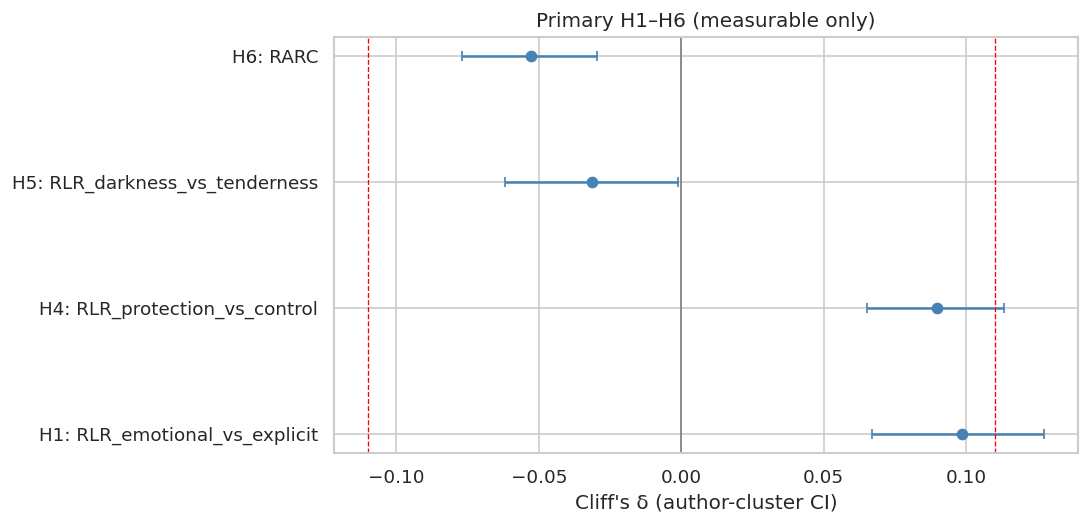

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_p = primary_view.dropna(subset=["cliffs_delta"]).copy()
plot_p = plot_p[plot_p["measurement_gate"] != "unmeasurable"]
if len(plot_p):
    y = np.arange(len(plot_p))
    ax.errorbar(
        plot_p["cliffs_delta"],
        y,
        xerr=[
            plot_p["cliffs_delta"] - plot_p["ci_low"],
            plot_p["ci_high"] - plot_p["cliffs_delta"],
        ],
        fmt="o",
        color="steelblue",
        capsize=3,
    )
    ax.axvline(0, color="gray", lw=1)
    ax.axvline(GATE, color="red", ls="--", lw=0.8)
    ax.axvline(-GATE, color="red", ls="--", lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_p["hypothesis"] + ": " + plot_p["feature"])
    ax.set_xlabel("Cliff's δ (author-cluster CI)")
    ax.set_title("Primary H1–H6 (measurable only)")
    ctx.save_figure(fig, "primary_h1_h6_forest")
plt.show()

## Section 10 — Component / secondary analysis

Not part of the primary FDR family. Confirmatory claim atoms (emotional security,
appearance) sit here alongside thin / exploratory components.

In [5]:
component_mask = ~effects["feature"].isin(PRIMARY_FEATURES)
components = effects.loc[component_mask].copy()
display(components[
    [
        c
        for c in [
            "hypothesis",
            "feature",
            "label",
            "measurement_gate",
            "cliffs_delta",
            "ci_low",
            "ci_high",
            "spearman_rho",
            "quality_beta",
            "quality_p",
            "verdict",
        ]
        if c in components.columns
    ]
].round(4))
ctx.save_table(components, "component_effects")

CLAIM_HIERARCHY = [
    ("confirmatory", "H3", "RAX_h3_emotional_side", "Emotional reassurance/security positively associated with rating quality"),
    ("confirmatory", "H3", "RAX_appearance_grooming", "Appearance/grooming description negatively associated with rating quality"),
    ("qualified", "H5", "RAX_external_danger_crisis", "External danger positively associated with ratings"),
    ("open", "H4", "RAX_external_protection", "Is enacted protection within danger the attractive feature? (thin: 1 topic)"),
    ("unsupported", "H4", "RAX_protective_commitment", "Generic protective promises do not distinguish high-rated romance"),
    ("unmeasurable", "H3", "RLR_emotional_vs_material_security", "Material/economic security not cleanly captured at topic level"),
    ("unmeasurable", "H4", "RLR_protection_vs_control", "Protective commitment atom empty; protection side thin"),
]
claims_rows = []
for tier, hyp, feat, claim in CLAIM_HIERARCHY:
    row = effects[effects["feature"] == feat]
    claims_rows.append(
        {
            "claim_tier": tier,
            "hypothesis": hyp,
            "feature": feat,
            "claim": claim,
            "measurement_gate": row.iloc[0]["measurement_gate"] if len(row) else "missing",
            "cliffs_delta": float(row.iloc[0]["cliffs_delta"]) if len(row) else float("nan"),
            "verdict": row.iloc[0]["verdict"] if len(row) else "missing",
        }
    )
claims_df = pd.DataFrame(claims_rows)
display(claims_df.round(4))
ctx.save_table(claims_df, "post_freeze_claim_hierarchy")

,hypothesis,feature,label,measurement_gate,cliffs_delta,ci_low,ci_high,spearman_rho,quality_beta,quality_p,verdict
6,H1,RAX_emotional_reassurance,emotional reassurance,viable,0.1364,0.1046,0.1678,0.0960,0.2402,0.0165,clears_gate
7,H1,RAX_explicit_sex,explicit sex,viable,-0.0753,-0.1040,-0.0437,-0.0527,0.2094,0.5828,directional_only
8,H1,RAX_nonexplicit_affection,non-explicit affection,viable,0.0343,0.0072,0.0658,0.0241,0.8583,0.0045,directional_only
9,H3,RAX_h3_emotional_side,emotional security side,viable,0.0602,0.0309,0.0891,0.0423,0.2277,0.3472,directional_only
10,H3,RAX_h3_material_side,material provision side,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable
11,H3,RAX_appearance_grooming,appearance / grooming,viable,-0.1424,-0.1701,-0.1143,-0.1000,-3.4644,0.0000,clears_gate
12,H4,RAX_external_protection,external protection (atom),thin,0.1597,0.1328,0.1880,0.1123,7.5185,0.0000,thin:clears_gate
13,H4,RAX_protective_commitment,protective commitment,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable
14,H4,RAX_h4_possession_side,possession / control,viable,0.0426,0.0141,0.0695,0.0301,0.4613,0.1147,directional_only
15,H5,RAX_tenderness_core,tenderness core,viable,0.1347,0.1040,0.1646,0.0950,0.5447,0.0000,clears_gate


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/component_effects.csv  (15 rows)


,claim_tier,hypothesis,feature,claim,measurement_gate,cliffs_delta,verdict
0,confirmatory,H3,RAX_h3_emotional_side,Emotional reassurance/security positively asso...,viable,0.0602,directional_only
1,confirmatory,H3,RAX_appearance_grooming,Appearance/grooming description negatively ass...,viable,-0.1424,clears_gate
2,qualified,H5,RAX_external_danger_crisis,External danger positively associated with rat...,viable,0.1159,clears_gate
3,open,H4,RAX_external_protection,Is enacted protection within danger the attrac...,thin,0.1597,thin:clears_gate
4,unsupported,H4,RAX_protective_commitment,Generic protective promises do not distinguish...,unmeasurable,NaN,unmeasurable
5,unmeasurable,H3,RLR_emotional_vs_material_security,Material/economic security not cleanly capture...,unmeasurable,NaN,unmeasurable
6,unmeasurable,H4,RLR_protection_vs_control,Protective commitment atom empty; protection s...,thin,0.0898,"thin:directionally consistent, effect below th..."


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/post_freeze_claim_hierarchy.csv  (7 rows)


## Section 11 — H6 arc panel

In [6]:
arc_cols = [
    c
    for c in [
        "RAX_arc_rising_begin",
        "RAX_arc_rising_end",
        "RAX_arc_falling_begin",
        "RAX_arc_falling_end",
        "DELTA_rising",
        "DELTA_falling",
        "RARC",
    ]
    if c in work.columns
]
arc_medians = work[arc_cols].median().rename("median").to_frame()
arc_medians["mean"] = work[arc_cols].mean()
display(arc_medians.round(5))
ctx.save_table(arc_medians.reset_index().rename(columns={"index": "feature"}), "h6_arc_medians")

h6_feats = effects[effects["hypothesis"] == "H6"].copy()
display(h6_feats[
    [c for c in ["feature", "label", "cliffs_delta", "ci_low", "ci_high", "quality_beta", "quality_p", "verdict"] if c in h6_feats.columns]
].round(4))
ctx.save_table(h6_feats, "h6_arc_effects")

,median,mean
RAX_arc_rising_begin,0.0405,0.0417
RAX_arc_rising_end,0.0470,0.0478
RAX_arc_falling_begin,0.0142,0.0155
RAX_arc_falling_end,0.0145,0.0158
DELTA_rising,0.0060,0.0060
DELTA_falling,0.0001,0.0003
RARC,0.0055,0.0057


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/h6_arc_medians.csv  (7 rows)


,feature,label,cliffs_delta,ci_low,ci_high,quality_beta,quality_p,verdict
5,RARC,refined arc contrast,-0.0528,-0.0769,-0.0297,-0.3952,0.0206,contradicted
19,DELTA_rising,rising Δ (end−begin),-0.0981,-0.1218,-0.0759,-1.0206,0.0000,directional_only
20,DELTA_falling,falling Δ (end−begin),-0.0821,-0.1050,-0.0595,-2.0588,0.0000,directional_only


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/h6_arc_effects.csv  (3 rows)


## Section 12 — Secondary Goodreads reach (discriminant)

Same final constructs against `log_n_ratings`. **Not** part of H1–H6 support verdicts.

In [7]:
reach_view = effects[
    [
        c
        for c in [
            "hypothesis",
            "feature",
            "label",
            "measurement_gate",
            "reach_beta",
            "reach_p",
            "cliffs_delta",
            "quality_beta",
            "verdict",
        ]
        if c in effects.columns
    ]
].copy()
reach_view = reach_view[reach_view["measurement_gate"] != "unmeasurable"]
display(reach_view.round(4))
ctx.save_table(reach_view, "reach_secondary_effects")

,hypothesis,feature,label,measurement_gate,reach_beta,reach_p,cliffs_delta,quality_beta,verdict
0,H1,RLR_emotional_vs_explicit,emotional vs explicit ratio,viable,-0.2038,0.0000,0.0986,-0.0075,"directionally consistent, effect below threshold"
3,H4,RLR_protection_vs_control,protection vs possession,thin,-0.0464,0.0000,0.0898,0.0024,"thin:directionally consistent, effect below th..."
4,H5,RLR_darkness_vs_tenderness,darkness vs tenderness,viable,0.1647,0.0042,-0.0315,-0.0097,contradicted
5,H6,RARC,refined arc contrast,viable,-1.6191,0.2286,-0.0528,-0.3952,contradicted
6,H1,RAX_emotional_reassurance,emotional reassurance,viable,4.9718,0.0000,0.1364,0.2402,clears_gate
7,H1,RAX_explicit_sex,explicit sex,viable,22.0320,0.0000,-0.0753,0.2094,directional_only
8,H1,RAX_nonexplicit_affection,non-explicit affection,viable,-13.3675,0.0000,0.0343,0.8583,directional_only
9,H3,RAX_h3_emotional_side,emotional security side,viable,3.4698,0.0488,0.0602,0.2277,directional_only
11,H3,RAX_appearance_grooming,appearance / grooming,viable,21.2397,0.0000,-0.1424,-3.4644,clears_gate
12,H4,RAX_external_protection,external protection (atom),thin,-10.0367,0.3515,0.1597,7.5185,thin:clears_gate


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/reach_secondary_effects.csv  (17 rows)


## Section 13 — Robustness traffic-light (from NB11; no re-run)

In [8]:
try:
    stab = pres.load_notebook_table(cfg, "11_refined_robustness", "stability_summary")
    traffic = pres.traffic_light_from_stability(stab, gate=GATE)
    display(traffic)
    ctx.save_table(traffic, "robustness_traffic_light")
except FileNotFoundError as exc:
    print(f"NB11 stability_summary not found ({exc}); skipping traffic-light.")
    traffic = pd.DataFrame()

,feature,measurement_gate,sign_stable,clears_gate_any_spec,min_abs_delta,max_abs_delta,light,overall
0,RLR_emotional_vs_explicit,viable,True,False,0.0626,0.1075,⚠,moderate (below gate in some specs)
1,RAX_h2_strict,unmeasurable,False,False,0.0000,0.0720,—,unmeasurable
2,RLR_emotional_vs_material_security,unmeasurable,False,False,0.0010,0.0602,—,unmeasurable
3,RLR_protection_vs_control,thin,True,False,0.0044,0.0899,⚠,thin / provisional
4,RLR_darkness_vs_tenderness,viable,False,False,0.0026,0.0315,✗,sensitive
5,RARC,viable,True,False,0.0434,0.0528,⚠,moderate (below gate in some specs)
6,RAX_explicit_sex,viable,True,False,0.0168,0.1003,⚠,moderate (below gate in some specs)
7,RAX_nonexplicit_affection,viable,True,False,0.0011,0.0740,⚠,moderate (below gate in some specs)
8,RAX_appearance_grooming,viable,True,True,0.0996,0.1424,✓,strong
9,RAX_status_display,unmeasurable,False,False,0.0000,0.0401,—,unmeasurable


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/robustness_traffic_light.csv  (17 rows)


## Section 14 — Final verdict table

Supported / directional / contradicted / unmeasurable / inconclusive — presentation source of truth.

In [9]:
VERDICT_NOTES = {
    "H1": "Primary emotional-vs-explicit contrast under refined measurement.",
    "H2": "Strict HEA/final-payoff operationalisation; broad HEA remains exploratory.",
    "H3": "Primary ratio unmeasurable after material-side freeze; report emotional security (+) and appearance (−) as confirmatory components.",
    "H4": "Primary ratio unmeasurable; protection atom thin (t119); possession viable; protection×danger is exploratory (NB14).",
    "H5": "Darkness-vs-tenderness primary plus qualified external-danger component.",
    "H6": "Refined arc contrast (RARC) and begin→end deltas; no mixed-effects extension.",
}
final_verdict = pres.final_verdict_rows(primary_view, claim_notes=VERDICT_NOTES)
display(final_verdict)
ctx.save_table(final_verdict, "final_verdict_table")

md_lines = [
    "# Final H1–H6 verdicts (Notebook 13)",
    "",
    "Source of truth for confirmatory claims. Exploratory patterns belong in Notebook 14.",
    "",
]
for _, r in final_verdict.iterrows():
    md_lines.append(
        f"- **{r['hypothesis']}** [{r['final_bucket']}]: {r['one_sentence']} "
        f"(δ={r['cliffs_delta'] if pd.notna(r['cliffs_delta']) else '—'}; "
        f"gate={r['measurement_gate']}; raw={r['verdict_raw']})"
    )
ctx.save_markdown("\n".join(md_lines) + "\n", "final_verdict_table")

# Side-by-side Stage 10 freeze vs refined primary δ
side = []
mapping = {h: (f, delta_freeze.get(h)) for h, f, _, _ in PRIMARY}
for hyp, (feat, old) in mapping.items():
    row = effects[effects["feature"] == feat]
    side.append(
        {
            "hypothesis": hyp,
            "original_delta": old,
            "refined_feature": feat,
            "refined_delta": float(row.iloc[0]["cliffs_delta"]) if len(row) else np.nan,
            "measurement_gate": row.iloc[0]["measurement_gate"] if len(row) else "missing",
            "refined_verdict": row.iloc[0]["verdict"] if len(row) else "missing",
        }
    )
side_df = pd.DataFrame(side)
display(side_df)
ctx.save_table(side_df, "stage10_vs_final_side_by_side")

print(
    "Notebook 13 complete. Do not redefine constructs from these results. "
    "Use Notebook 14 for presentation / exploratory interpretation."
)

,hypothesis,feature,measurement_gate,cliffs_delta,verdict_raw,final_bucket,one_sentence
0,H1,RLR_emotional_vs_explicit,viable,0.0986,"directionally consistent, effect below threshold",directional,Primary emotional-vs-explicit contrast under r...
1,H2,RAX_h2_strict,unmeasurable,NaN,unmeasurable,unmeasurable,Strict HEA/final-payoff operationalisation; br...
2,H3,RLR_emotional_vs_material_security,unmeasurable,NaN,unmeasurable,unmeasurable,Primary ratio unmeasurable after material-side...
3,H4,RLR_protection_vs_control,thin,0.0898,"thin:directionally consistent, effect below th...",inconclusive,Primary ratio unmeasurable; protection atom th...
4,H5,RLR_darkness_vs_tenderness,viable,-0.0315,contradicted,contradicted,Darkness-vs-tenderness primary plus qualified ...
5,H6,RARC,viable,-0.0528,contradicted,contradicted,Refined arc contrast (RARC) and begin→end delt...


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/final_verdict_table.csv  (6 rows)
  saved markdown: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/final_verdict_table.md


,hypothesis,original_delta,refined_feature,refined_delta,measurement_gate,refined_verdict
0,H1,-0.0290,RLR_emotional_vs_explicit,0.0986,viable,"directionally consistent, effect below threshold"
1,H2,0.0270,RAX_h2_strict,NaN,unmeasurable,unmeasurable
2,H3,-0.1460,RLR_emotional_vs_material_security,NaN,unmeasurable,unmeasurable
3,H4,0.0900,RLR_protection_vs_control,0.0898,thin,"thin:directionally consistent, effect below th..."
4,H5,0.0120,RLR_darkness_vs_tenderness,-0.0315,viable,contradicted
5,H6,0.0440,RARC,-0.0528,viable,contradicted


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/13_final_statistical_tests/tables/stage10_vs_final_side_by_side.csv  (6 rows)
Notebook 13 complete. Do not redefine constructs from these results. Use Notebook 14 for presentation / exploratory interpretation.
